
# Target-Event-Agent Networks (TEA Nets) Tutorial
This tutorial introduces the **concepts** behind the Target-Event-Agent (TEA) network framework and shows how to read a TEA network. TEA networks provide a unique approach to narrative analysis by focusing on the actors (Agent), actions (Event), and consequences (Target) portrayed in texts, constructing a multilayer semantic-syntactic network.

The TEA framework is available at https://github.com/MassimoStel/TEA_Networks.git.

> 📦 **Looking for installation and a hands-on usage walkthrough?** This notebook is the *conceptual* companion. For the **full install guide** (`venv` / `uv` / `conda` + Google Colab) and the practical API walkthrough, see the **[Starting Guide](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Starting%20Guide.ipynb)**. For advanced analytics, see **[Analyzing TEA](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Analyzing%20TEA.ipynb)**.

## 1. Introduction to TEA Nets.
TEA Nets are a framework designed to analyze narratives core components: actors, actions, and consequences. These semantic/syntactic multilayer networks consist of three primary layers:

* Subjects/Actors (Agent): The entities performing actions.
* Verbs/Consequences (Event): The verbs connecting subjects to objects, often indicating consequences.
* Objects/Actions (Target): The actions being performed.

## 2. Setup

The full installation guide lives in the [Starting Guide](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Starting%20Guide.ipynb). In short:

- **On Google Colab:** uncomment the two lines in the **Setup** cell below and run it (first run ~3–4 min, then *Runtime → Restart session*).
- **Locally:** install `teanets` (see the Starting Guide), then run the cell as-is.

In [ ]:
# ── Setup ──────────────────────────
# ▶ ON GOOGLE COLAB (or any fresh environment): uncomment the two lines below.
#   First run only — takes ~3-4 min (downloads the spaCy transformer model).
#   On Colab, do "Runtime > Restart session" once afterwards, then re-run.
# !pip install -q --retries 10 --timeout 120 git+https://github.com/MassimoStel/TEA_Networks.git
# !python -m spacy download en_core_web_trf

# ▶ LOCAL CLONE: if you run this notebook from inside the cloned repository
#   (Docs & Guides/), the lines below let `import teanets` work without
#   installing the package. They are harmless if teanets is already installed.
import sys, os
_repo_root = os.path.abspath("..")
if os.path.isdir(os.path.join(_repo_root, "teanets")):
    sys.path.insert(0, _repo_root)

# All imports in one place:
import teanets as tea
import teanets.analytics
import teanets.teaplot as teaplot
print(f"teanets {tea.__version__} ready")

## 3. Basic example

As a minimal example, we will process the sentence:  
> "Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic."

We will load the text, extract the SVOs and plot the TEA graph.

In [3]:
text = """Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic."""

In [4]:
svo = tea.extract_svos_from_text(text)

Inference: 100%|██████████| 1/1 [00:00<00:00, 24.27it/s]
[nltk_data] Downloading package wordnet to /home/seb/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
display(svo)

,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,alex,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
1,ben,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
2,care,Event,for animal,Target,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
3,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
4,alex,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
5,ben,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
6,love hike,Event,through national park,Target,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
7,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
8,alex,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0
9,ben,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0


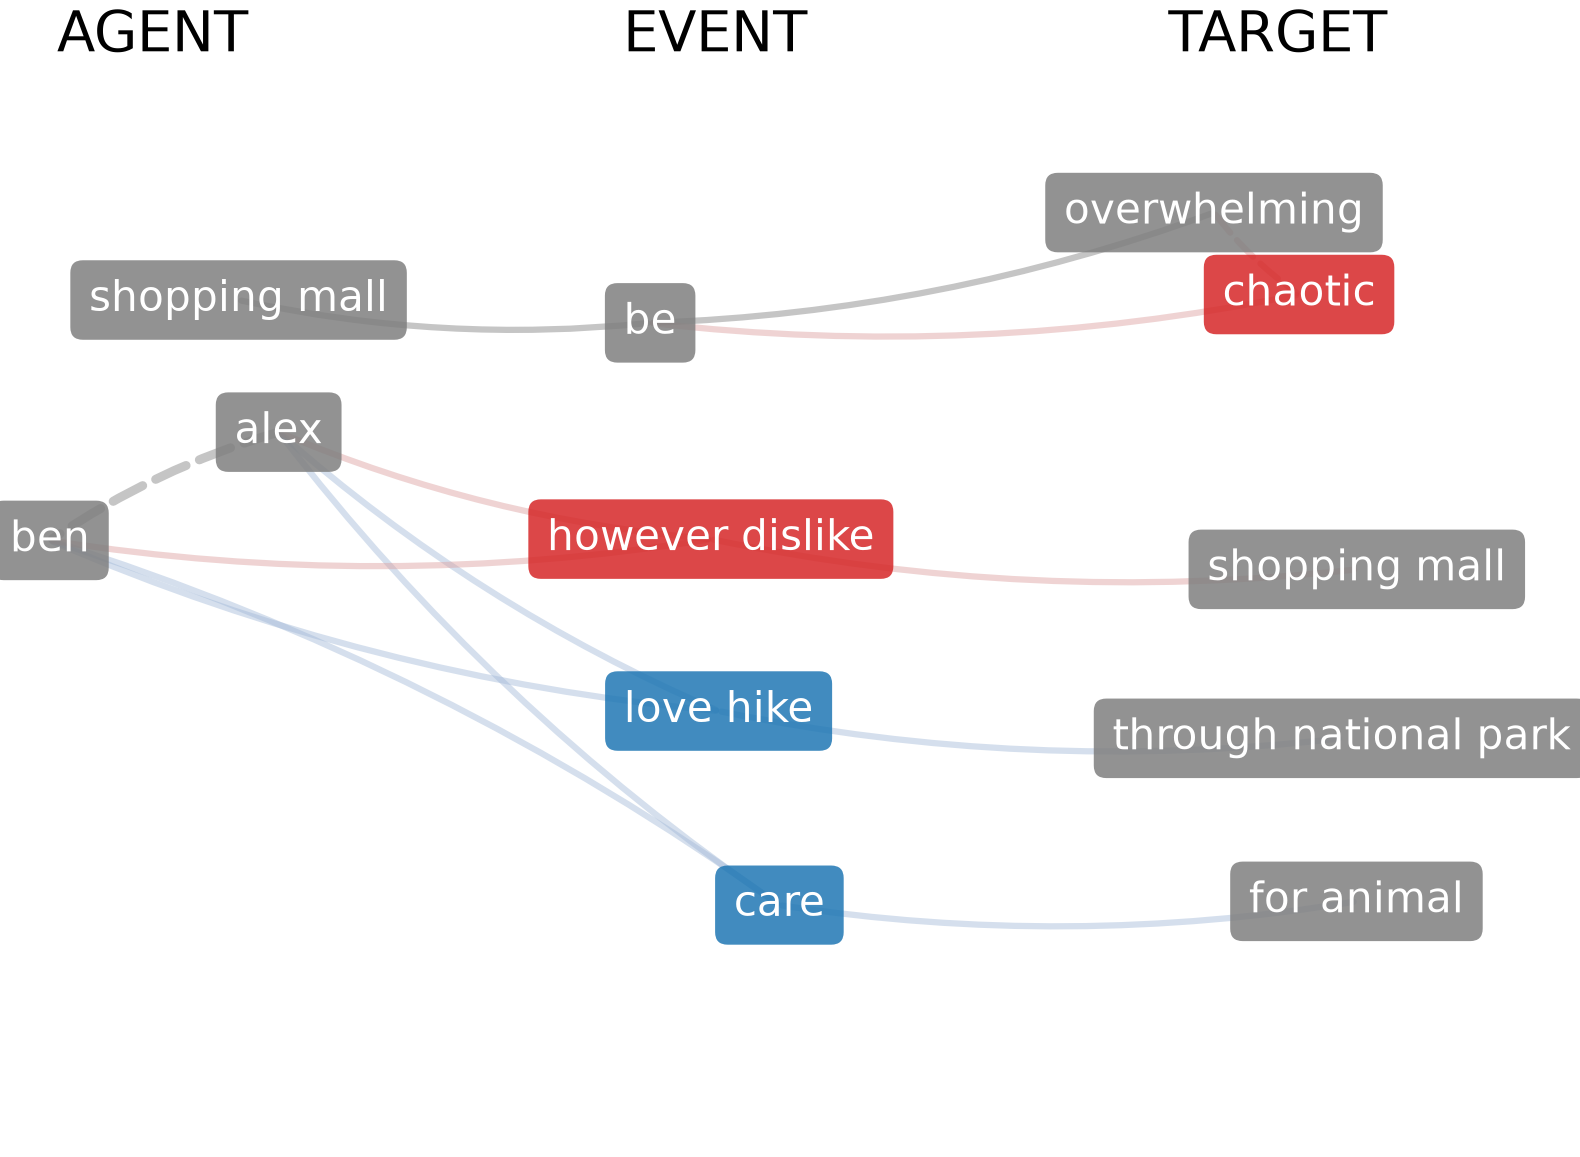

In [6]:
teaplot.plot_svo_graph(
    svo,
    custom_font=30
)

Part-of-speech tagging is determined by an AI model (specifically, spaCy) analyzing each sentence in a text. Inter-layer connections are established using a rule-based approach applied to the syntactic parsing provided by spaCy. Intra-layer connections are semantic, established only if two words are synonyms (e.g., "father" and "dad").

Like in textual forma mentis networks, individual concepts are labeled as 'positive' (cyan), 'negative' (red), and 'neutral' (gray) according to **Vader** Sentiment Analysis. Inter-layer paths indicate 'target event agent' – i.e., which actions and which consequences were portrayed by specific agents in texts. While tools like EmoAtlas provide general results about the overall context of biased perceptions, TEA networks complement Textual Forma Mentis Networks (TFMNs) by offering a granular focus on actors, actions, and consequences.


## 4. Full Example / Recap
The following cell contains the complete code for extracting SVOs and plotting the TEA Network, all in one place.

In [ ]:
# Full example / recap — uses the imports from the Setup cell at the top.
text = "Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic"
svo = tea.extract_svos_from_text(text)
display(svo)
teaplot.plot_svo_graph(svo, custom_font=20)